# Anchored Posterior Sampling (APS) for Diffusion Language Models

This notebook demonstrates **Anchored Posterior Sampling (APS)** on Dream-7B-Instruct, a masked diffusion language model.

**Key Features:**
- **Quantized Expectation (QE)**: Enables gradient-based optimization in discrete token space
- **Anchored Remasking**: Adaptively preserves high-confidence tokens during generation
- **Reward-Guided Generation**: Uses lightweight reward models to improve output quality

**Reference:** [APS Paper](https://arxiv.org/abs/2510.02291)

## 1. Setup and Imports

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 999
torch.manual_seed(SEED)

/home/ssn899/miniforge3/envs/aps/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:1


## 2. Configuration

In [2]:
# Model configurations
DREAM_MODEL = "Dream-org/Dream-v0-Instruct-7B"

# Reward model for optimization (lightweight for speed!)
REWARD_MODEL = "Skywork/Skywork-Reward-V2-Qwen3-0.6B"

# APS hyperparameters
config = {
    "T": 128,                 # Diffusion steps
    "M": 3,                   # Optimization steps per diffusion step
    "eta": 0.1,               # Learning rate for reward optimization
    "max_new_tokens": 128,    # Maximum tokens to generate
    "temperature": 0.2,       # Sampling temperature for token selection
    "alg_temp": 0.0,          # Temperature for remasking
    "top_p": 0.95,            # Top-p sampling
}

print("Configuration:")
print(f"  Dream Model: {DREAM_MODEL}")
print(f"  Reward Model: {REWARD_MODEL}")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration:
  Dream Model: Dream-org/Dream-v0-Instruct-7B
  Reward Model: Skywork/Skywork-Reward-V2-Qwen3-0.6B
  T: 128
  M: 3
  eta: 0.1
  max_new_tokens: 128
  temperature: 0.2
  alg_temp: 0.0
  top_p: 0.95


## 3. Load Models

In [3]:
def load_models(dream_path, reward_path, device):
    """Load Dream (diffusion) and Skywork (reward) models"""
    print(f"Loading Dream model from: {dream_path}")
    dream_model = AutoModel.from_pretrained(
        dream_path, 
        torch_dtype=torch.bfloat16, 
        trust_remote_code=True
    )
    dream_tokenizer = AutoTokenizer.from_pretrained(dream_path, trust_remote_code=True)
    dream_model = dream_model.to(device).eval()
    
    print(f"Loading reward model from: {reward_path}")
    reward_model = AutoModelForSequenceClassification.from_pretrained(
        reward_path,
        torch_dtype=torch.bfloat16,
        device_map=device,
        num_labels=1,
        trust_remote_code=True,  # Required for Qwen3 models
    )
    reward_tokenizer = AutoTokenizer.from_pretrained(reward_path, trust_remote_code=True)
    reward_model.eval()

    for param in reward_model.parameters():
        param.requires_grad = False
    
    return dream_model, dream_tokenizer, reward_model, reward_tokenizer

# Load models
dream_model, dream_tokenizer, reward_model, reward_tokenizer = load_models(
    DREAM_MODEL, REWARD_MODEL, device
)

print("\nModels loaded successfully!")
print(f"Dream vocab size: {dream_model.lm_head.out_features}")
print(f"Dream mask token ID: {dream_tokenizer.mask_token_id}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Dream model from: Dream-org/Dream-v0-Instruct-7B


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 207.49it/s]
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading reward model from: Skywork/Skywork-Reward-V2-Qwen3-0.6B

Models loaded successfully!
Dream vocab size: 152064
Dream mask token ID: 151666


## 4. Token Mapping Between Vocabularies

Since Dream and Skywork use different tokenizers, we need to create a mapping between their vocabularies.

In [4]:
def create_token_mapping(dream_tokenizer, reward_tokenizer, dream_model_vocab_size):
    """Create mapping from Dream vocab to Reward vocab"""
    dream_vocab = dream_tokenizer.get_vocab()
    reward_vocab = reward_tokenizer.get_vocab()
    
    unk_id = reward_tokenizer.unk_token_id if reward_tokenizer.unk_token_id is not None else 0
    mapping_tensor = torch.full((dream_model_vocab_size,), unk_id, dtype=torch.long)
    
    matched_count = 0
    for dream_token_str, dream_id in dream_vocab.items():
        if dream_id >= dream_model_vocab_size:
            continue
        if dream_token_str in reward_vocab:
            reward_id = reward_vocab[dream_token_str]
            mapping_tensor[dream_id] = reward_id
            matched_count += 1
    
    print(f"Token mapping: {matched_count}/{dream_model_vocab_size} tokens matched")
    return mapping_tensor

# Create token mapping
dream_model_vocab_size = dream_model.lm_head.out_features
token_mapping = create_token_mapping(
    dream_tokenizer, reward_tokenizer, dream_model_vocab_size
).to(device)

# Get mapped embeddings for soft reward computation
reward_embed_layer = reward_model.get_input_embeddings()
mapped_embeddings = reward_embed_layer.weight[token_mapping].detach().to(device)
print(f"Mapped embeddings shape: {mapped_embeddings.shape}")

Token mapping: 151665/152064 tokens matched
Mapped embeddings shape: torch.Size([152064, 1024])


## 5. Reward Computation Functions

In [5]:
def compute_reward_with_embeddings(
    reward_model,
    reward_tokenizer,
    dream_tokenizer,
    prompt_ids,
    response_embeds,
    response_token_ids,
    device
):
    """
    Compute reward using embeddings while respecting chat template.
    Uses soft embeddings for differentiable reward computation.
    """
    # Extract user content from prompt
    prompt_text = dream_tokenizer.decode(prompt_ids[0], skip_special_tokens=False)
    if "<|im_start|>user\n" in prompt_text:
        user_content = prompt_text.split("<|im_start|>user\n")[1].split("<|im_end|>")[0]
    else:
        user_content = prompt_text
    
    # Use a unique placeholder
    PLACEHOLDER = "<<RESPONSE_PLACEHOLDER>>"
    
    conversation = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": PLACEHOLDER}
    ]
    
    full_template = reward_tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=False
    )
    
    prefix_text, suffix_text = full_template.split(PLACEHOLDER, 1)
    
    # Tokenize and find placeholder position
    full_ids = reward_tokenizer(full_template, return_tensors="pt").input_ids[0].to(device)
    placeholder_ids = reward_tokenizer(PLACEHOLDER, add_special_tokens=False, return_tensors="pt").input_ids[0].to(device)
    
    placeholder_len = len(placeholder_ids)
    found = False
    
    for i in range(len(full_ids) - placeholder_len + 1):
        if torch.all(full_ids[i:i + placeholder_len] == placeholder_ids):
            prefix_ids = full_ids[:i]
            suffix_ids = full_ids[i + placeholder_len:]
            found = True
            break
    
    if not found:
        prefix_ids = reward_tokenizer(prefix_text, return_tensors="pt").input_ids[0].to(device)
        suffix_ids = reward_tokenizer(suffix_text, return_tensors="pt").input_ids[0].to(device)
    
    # Get embeddings
    embed_layer = reward_model.get_input_embeddings()
    prefix_embeds = embed_layer(prefix_ids.unsqueeze(0))
    suffix_embeds = embed_layer(suffix_ids.unsqueeze(0))
    
    # Concatenate: prefix + response + suffix
    full_embeds = torch.cat([prefix_embeds, response_embeds, suffix_embeds], dim=1)
    
    # Create attention mask (mask special tokens)
    prefix_len = prefix_embeds.shape[1]
    response_len = response_embeds.shape[1]
    suffix_len = suffix_embeds.shape[1]
    
    attention_mask = torch.ones(1, prefix_len + response_len + suffix_len, device=device, dtype=torch.long)
    
    special_token_ids = [
        dream_tokenizer.pad_token_id, 
        dream_tokenizer.mask_token_id,
    ]
    special_token_ids = [tid for tid in special_token_ids if tid is not None]
    
    eos_token_id = reward_tokenizer.eos_token_id
    eos_found = False
    for i, token_id in enumerate(response_token_ids):
        if token_id.item() in special_token_ids or (token_id.item() == eos_token_id and eos_found):
            attention_mask[0, prefix_len + i] = 0
        if token_id.item() == eos_token_id:
            eos_found = True
    
    outputs = reward_model(inputs_embeds=full_embeds, attention_mask=attention_mask)
    reward = outputs.logits[0][0]
    
    return reward


def compute_final_reward(reward_model, reward_tokenizer, prompt, response, device):
    """Compute discrete (non-differentiable) reward for final evaluation."""
    conversation = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response}
    ]
    
    formatted = reward_tokenizer.apply_chat_template(conversation, tokenize=False)
    
    if reward_tokenizer.bos_token is not None and formatted.startswith(reward_tokenizer.bos_token):
        formatted = formatted[len(reward_tokenizer.bos_token):]
    
    inputs = reward_tokenizer(formatted, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = reward_model(**inputs)
        reward = outputs.logits[0][0].item()
    
    return reward

print("Reward functions defined!")

Reward functions defined!


## 6. APS Step Function

The core of the APS algorithm: a single denoising step with reward-guided optimization.

In [6]:
def top_p_logits(logits, top_p):
    """Filter a distribution of logits using nucleus (top-p) filtering"""
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    
    # Remove tokens with cumulative probability above the threshold
    sorted_indices_to_remove = cumulative_probs > top_p
    # Shift the indices to the right to keep also the first token above the threshold
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = False
    
    # Scatter sorted tensors to original indexing
    indices_to_remove = sorted_indices_to_remove.scatter(
        dim=-1, index=sorted_indices, src=sorted_indices_to_remove
    )
    logits = logits.masked_fill(indices_to_remove, float('-inf'))
    return logits


def sample_tokens_aps(logits, temperature=0.0, top_p=None, neg_entropy=True):
    """
    Sample tokens using Dream's exact sampling method.
    This matches Dream's sample_tokens function to ensure identical behavior at eta=0.
    """
    import torch.distributions as dists
    
    working_logits = logits.clone()
    
    if temperature > 0:
        working_logits = working_logits / temperature
    if top_p is not None and top_p < 1:
        working_logits = top_p_logits(working_logits, top_p)
    
    probs = torch.softmax(working_logits, dim=-1)
    
    if temperature > 0:
        try:
            sampled_tokens = dists.Categorical(probs=probs).sample()
            confidence = torch.gather(probs, -1, sampled_tokens.unsqueeze(-1)).squeeze(-1)
        except:
            confidence, sampled_tokens = probs.max(dim=-1)
    else:
        confidence, sampled_tokens = probs.max(dim=-1)
    
    if neg_entropy:
        epsilon = 1e-10
        log_probs = torch.log(probs + epsilon)
        confidence = torch.sum(probs * log_probs, dim=-1)
    
    return confidence, sampled_tokens


def aps_step(
    dream_model,
    reward_model,
    reward_tokenizer,
    dream_tokenizer,
    z_t,
    prompt_ids,
    mask_token_id,
    token_mapping,
    reward_embed_layer,
    mapped_embeddings,
    device,
    M=5,
    eta=1.0,
    temperature=0.0,
    top_p=0.95,
    step_idx=0,
    total_steps=1,
    alg_temp=0.0,
):
    """
    Single APS step - optimizes logits directly and samples from optimized logits.
    
    The key insight: We optimize phi (logits) using soft embedding gradients,
    but the final sampling should be from phi directly (not embedding similarity).
    
    The QE trick allows gradients to flow through discrete samples, so optimizing
    phi to increase reward DOES change the discrete token distribution in a
    meaningful way.
    """
    # Check if done (no masks remaining)
    mask_positions = (z_t == mask_token_id)
    num_masks = mask_positions.sum().item()
    
    if num_masks == 0:
        return z_t, 0, 0.0
    
    response_start = prompt_ids.shape[1]
    response_mask_positions = mask_positions[:, response_start:]
    masked_indices = torch.where(response_mask_positions[0])[0]
    
    # Get initial logits from denoiser
    with torch.no_grad():
        outputs = dream_model(z_t, attention_mask=None)
        logits = outputs.logits
        # Shift logits (Dream implementation detail)
        logits = torch.cat([logits[:, :1], logits[:, :-1]], dim=1)
    
    response_logits = logits[:, response_start:, :]
    
    # Initialize phi (logits at masked positions)
    phi_init = response_logits[0, masked_indices, :].clone().detach()
    
    # If eta is 0, skip optimization entirely (pure Dream behavior)
    if eta == 0 or M == 0:
        phi_optim = phi_init
        reward_value = 0.0
    else:
        # Optimization loop
        phi_optim = phi_init.clone().detach().requires_grad_(True)
        phi_optimizer = torch.optim.Adam([phi_optim], lr=eta)
        
        reward_value = 0.0
        for m in range(M):
            phi_optimizer.zero_grad()
            x_phi = F.softmax(phi_optim, dim=-1)  # [num_masked, vocab_size]
            
            # Sample hard tokens from current phi distribution (for QE)
            # Use argmax for deterministic hard samples during optimization
            hard_samples = torch.argmax(x_phi, dim=-1)
            
            # Build response with Quantized Expectation
            response_tokens = z_t[0, response_start:].clone()
            response_tokens[masked_indices] = hard_samples
            
            response_embeds_list = []
            for i in range(len(response_tokens)):
                token_id = response_tokens[i].item()
                
                if response_mask_positions[0, i]:
                    pos_in_masked = (masked_indices == i).nonzero(as_tuple=True)[0].item()
                    
                    # Hard path: the actual discrete token we'll use
                    hard_token_id = hard_samples[pos_in_masked].item()
                    reward_token_id = token_mapping[hard_token_id].item()
                    hard_embed = reward_embed_layer.weight[reward_token_id]
                    
                    # Soft path: weighted average for gradient flow
                    soft_prob = x_phi[pos_in_masked]
                    soft_embed = torch.matmul(soft_prob, mapped_embeddings)
                    
                    # QE trick: forward uses hard, backward uses soft
                    qe_embed = soft_embed + (hard_embed - soft_embed.detach())
                    response_embeds_list.append(qe_embed)
                else:
                    reward_token_id = token_mapping[token_id].item()
                    hard_embed = reward_embed_layer.weight[reward_token_id]
                    response_embeds_list.append(hard_embed.detach())
            
            response_embeds = torch.stack(response_embeds_list).unsqueeze(0)
            
            # Compute reward
            reward = compute_reward_with_embeddings(
                reward_model, reward_tokenizer, dream_tokenizer,
                prompt_ids, response_embeds, response_tokens, device
            )
            
            # Loss = negative reward (we want to maximize reward)
            loss = -reward
            reward_value = reward.item()
            
            loss.backward()
            phi_optimizer.step()
        
        # Detach after optimization
        phi_optim = phi_optim.detach()
    
    # Final sampling using anchored remasking: Sample from optimized phi using Dream's method
    # This is correct because QE gradients update phi to increase probability
    # of tokens that lead to higher reward
    confidence, sampled_tokens_final = sample_tokens_aps(
        phi_optim, 
        temperature=temperature, 
        top_p=top_p,
        neg_entropy=True
    )
    
    # Compute number of positions to unmask based on schedule
    t = (total_steps - step_idx) / total_steps
    s = (total_steps - step_idx - 1) / total_steps if step_idx < total_steps - 1 else 0
    
    num_to_unmask = int(num_masks * (1 - s / t)) if step_idx < total_steps - 1 else num_masks
    num_to_unmask = max(1, num_to_unmask)
    
    response_mask_flat_indices = torch.where(response_mask_positions[0])[0]
    
    # Select positions based on confidence
    if num_to_unmask < len(confidence):
        _, selected_positions = torch.topk(confidence, num_to_unmask)
    else:
        selected_positions = torch.arange(len(confidence), device=device)
    
    # Handle alg_temp for stochastic position selection
    if alg_temp > 0 and num_to_unmask < len(confidence):
        gumbel_noise = -torch.log(-torch.log(torch.rand_like(confidence) + 1e-10) + 1e-10)
        noisy_confidence = confidence + alg_temp * gumbel_noise
        _, selected_positions = torch.topk(noisy_confidence, num_to_unmask)
    
    # Update state: unmask selected positions
    z_s = z_t.clone()
    full_indices = response_start + response_mask_flat_indices[selected_positions]
    selected_tokens = sampled_tokens_final[selected_positions]
    z_s[0, full_indices] = selected_tokens
    
    num_masks_remaining = (z_s == mask_token_id).sum().item()
    
    return z_s, num_masks_remaining, reward_value

print("APS step function defined!")

APS step function defined!


## 7. Main APS Generation Function

In [7]:
def aps_generate(
    dream_model,
    dream_tokenizer,
    reward_model,
    reward_tokenizer,
    token_mapping,
    mapped_embeddings,
    prompt,
    max_new_tokens=128,
    T=64,
    M=5,
    eta=1.0,
    temperature=0.0,
    top_p=0.95,
    alg_temp=0.0,
    device='cuda:0',
    verbose=True,
):
    """
    Generate text using APS algorithm with Dream-compatible sampling.
    
    Args:
        T: Number of diffusion steps
        M: Number of optimization steps per diffusion step
        eta: Learning rate (guidance scale) - 0 means pure Dream baseline
        temperature: Sampling temperature (0 = deterministic)
        top_p: Nucleus sampling threshold (same as Dream)
        alg_temp: Temperature for position selection (same as Dream's alg_temp)
    
    Returns:
        response_text: Generated response
        history: List of intermediate states
        reward_history: List of rewards at each step
    """
    mask_token_id = dream_tokenizer.mask_token_id
    reward_embed_layer = reward_model.get_input_embeddings()
    
    # Prepare input
    messages = [{"role": "user", "content": prompt}]
    inputs = dream_tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True
    )
    prompt_ids = inputs.input_ids.to(device)
    
    # Initialize with all mask tokens
    z = F.pad(prompt_ids, (0, max_new_tokens), value=mask_token_id)
    
    if verbose:
        print(f"\n{'='*60}")
        print("ANCHORED POSTERIOR SAMPLING (APS)")
        print(f"{'='*60}")
        print(f"Prompt: {prompt}")
        print(f"Diffusion steps (T): {T}")
        print(f"Optimization steps (M): {M}")
        print(f"Learning rate (η): {eta}")
        print(f"Temperature: {temperature}")
        print(f"Top-p: {top_p}")
        print(f"Alg temp: {alg_temp}")
        print(f"Initial masks: {(z == mask_token_id).sum().item()}")
        print(f"{'='*60}\n")
    
    history = []
    reward_history = []
    
    for i in tqdm(range(T), desc="APS Decoding"):
        z, num_masks, reward_value = aps_step(
            dream_model=dream_model,
            reward_model=reward_model,
            reward_tokenizer=reward_tokenizer,
            dream_tokenizer=dream_tokenizer,
            z_t=z,
            prompt_ids=prompt_ids,
            mask_token_id=mask_token_id,
            token_mapping=token_mapping,
            reward_embed_layer=reward_embed_layer,
            mapped_embeddings=mapped_embeddings,
            device=device,
            M=M,
            eta=eta,
            temperature=temperature,
            top_p=top_p,
            alg_temp=alg_temp,
            step_idx=i,
            total_steps=T,
        )
        
        history.append(z.clone())
        reward_history.append(reward_value)
        
        if verbose and (i + 1) % 10 == 0:
            current_response = dream_tokenizer.decode(z[0, len(prompt_ids[0]):], skip_special_tokens=False)
            print(f"Step {i + 1}/{T} - Masks: {num_masks} - Reward: {reward_value:.4f}")
            print(f"Current: {current_response[:100]}...\n")
        
        if num_masks == 0:
            if verbose:
                print(f"\n✓ All masks filled at step {i + 1}/{T}")
            break
    
    # Decode final output - filter out invalid token IDs first
    response_ids = z[0, len(prompt_ids[0]):]
    # Filter out any token IDs that might cause decoding issues
    valid_response_ids = [tid.item() for tid in response_ids if tid.item() < dream_tokenizer.vocab_size]
    response_text = dream_tokenizer.decode(valid_response_ids, skip_special_tokens=True)
    
    return response_text, history, reward_history

print("APS generate function defined!")

APS generate function defined!


## 8. Baseline Generation (No APS)

Run standard Dream diffusion generation **without** reward guidance for comparison.

In [13]:
def baseline_generate(dream_model, dream_tokenizer, prompt, config, device):
    """
    Generate text using standard Dream diffusion decoding.
    No reward guidance - pure diffusion language model generation.
    """
    # Prepare input using chat template
    messages = [{"role": "user", "content": prompt}]
    inputs = dream_tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True
    )
    input_ids = inputs.input_ids.to(device)
    
    # Generate using Dream's built-in diffusion generation
    # Use same parameters as baseline notebook for fair comparison
    with torch.no_grad():
        output = dream_model.diffusion_generate(
            input_ids,
            max_new_tokens=config["max_new_tokens"],
            output_history=True,
            return_dict_in_generate=True,
            steps=config["T"],
            temperature=config["temperature"],
            alg="entropy",
            alg_temp=config.get("alg_temp", 0.0),
            top_p=config["top_p"],
        )
    
    # Decode response
    generated_ids = output.sequences[0]
    response_ids = generated_ids[len(input_ids[0]):]
    response_text = dream_tokenizer.decode(response_ids, skip_special_tokens=True)
    
    return response_text

# Test prompt - feel free to change this!
prompt = "Write a short poem about Generative AI."

print(f"{'='*60}")
print("BASELINE GENERATION (No APS - Standard Dream)")
print(f"{'='*60}")
print(f"Prompt: {prompt}")
print(f"{'='*60}\n")

# Generate baseline response
baseline_response = baseline_generate(
    dream_model=dream_model,
    dream_tokenizer=dream_tokenizer,
    prompt=prompt,
    config=config,
    device=device,
)

print(f"{'='*60}")
print("BASELINE RESPONSE")
print(f"{'='*60}")
print(baseline_response)

# Compute baseline reward with 0.6B model
baseline_reward = compute_final_reward(
    reward_model=reward_model,
    reward_tokenizer=reward_tokenizer,
    prompt=prompt,
    response=baseline_response,
    device=device,
)

print(f"\n{'='*60}")
print(f"Baseline Reward (0.6B): {baseline_reward:.4f}")
print(f"{'='*60}")

BASELINE GENERATION (No APS - Standard Dream)
Prompt: Write a short poem about Generative AI.

BASELINE RESPONSE
Generative AI, a powerful tool,
Creating art, music, and even fool.
From raw data, it can learn,
To find patterns, and creativity burn.

It can generate images, sounds, and text,
Creating new worlds, and new next.
It can generate stories, and games,
Creating new worlds, and new names.

Generative AI, a powerful tool,
Creating new worlds, and new rules.
From raw data, it can learn,
To find patterns, and creativity burn.

Baseline Reward (0.6B): 2.7188


## 9. Run APS Generation

In [27]:
# Generate using APS
response, history, reward_history = aps_generate(
    dream_model=dream_model,
    dream_tokenizer=dream_tokenizer,
    reward_model=reward_model,
    reward_tokenizer=reward_tokenizer,
    token_mapping=token_mapping,
    mapped_embeddings=mapped_embeddings,
    prompt=prompt,
    max_new_tokens=config["max_new_tokens"],
    T=config["T"],
    M=config["M"],
    eta=config["eta"],
    temperature=config["temperature"],
    top_p=config["top_p"],
    alg_temp=config.get("alg_temp", 0.0),
    device=device,
    verbose=True,
)

print(f"\n{'='*60}")
print("FINAL RESPONSE")
print(f"{'='*60}")
print(response)


ANCHORED POSTERIOR SAMPLING (APS)
Prompt: Write a short poem about Generative AI.
Diffusion steps (T): 128
Optimization steps (M): 3
Learning rate (η): 0.1
Temperature: 0.2
Top-p: 0.95
Alg temp: 0.0
Initial masks: 128



APS Decoding:   8%|▊         | 10/128 [00:03<00:41,  2.84it/s]

Step 10/128 - Masks: 118 - Reward: -4.1250
Current: Generative AI, a marvel of the mind,
<|mask|><|mask|><|mask|><|mask|><|mask|><|mask|><|mask|><|mask|...



APS Decoding:  16%|█▌        | 20/128 [00:06<00:36,  2.98it/s]

Step 20/128 - Masks: 108 - Reward: -2.8906
Current: Generative AI, a marvel of the mind,
Creating new art, music, and kind.
From<|mask|><|mask|><|mask|>...



...

Step 110/128 - Masks: 18 - Reward: 2.3750
Current: Generative AI, a marvel of the mind,
Creating new art, music, and kind.
From poetry to code, it's a ...



APS Decoding:  94%|█████████▍| 120/128 [00:34<00:01,  4.39it/s]

Step 120/128 - Masks: 8 - Reward: 4.9062
Current: Generative AI, a marvel of the mind,
Creating new art, music, and kind.
From poetry to code, it's a ...



APS Decoding:  99%|█████████▉| 127/128 [00:36<00:00,  3.46it/s]


✓ All masks filled at step 128/128

FINAL RESPONSE
Generative AI, a marvel of the mind,
Creating new art, music, and kind.
From poetry to code, it's a wonder to behold,
Opening new possibilities, it's so bold.

With algorithms and data, it's so smart,
Creating new worlds, stories, and art.
It's a tool for creativity, powerful and free,
Helping us to innovate and to see.

With Generative AI, the future is bright,
The possibilities are endless, it's so right.
So let's embrace it, let's explore it,
And let's see the magic that it can create.


## 10. Compute Final Reward

In [29]:
# Compute final discrete reward
final_reward = compute_final_reward(
    reward_model=reward_model,
    reward_tokenizer=reward_tokenizer,
    prompt=prompt,
    response=response,
    device=device,
)

print(f"Final Reward: {final_reward:.4f}")

Final Reward: 5.7188


## 11. Visualize Reward Progression

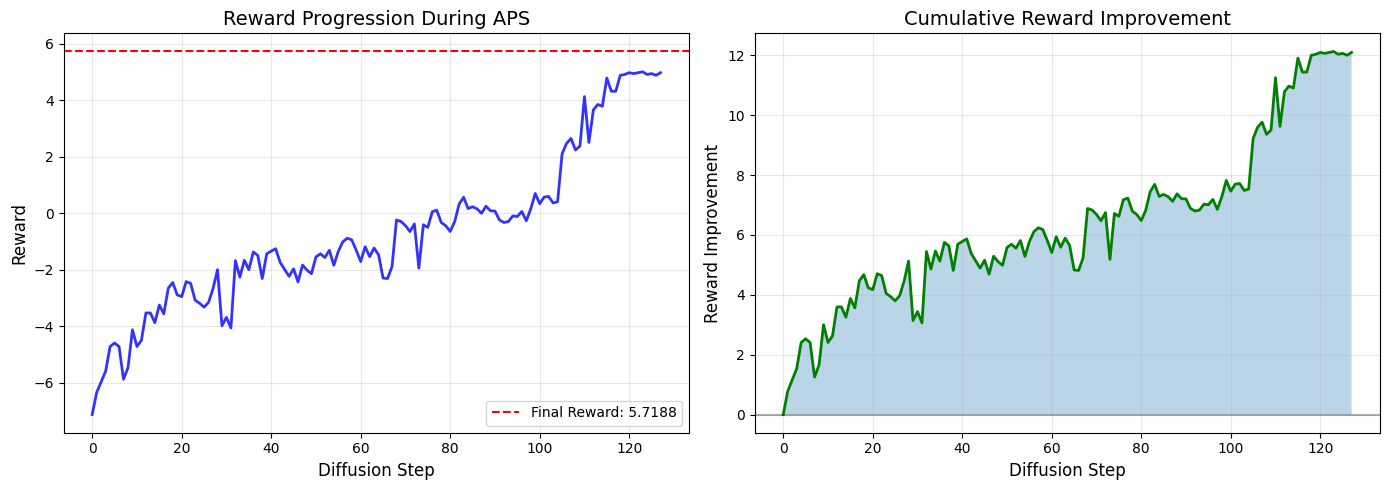


REWARD STATISTICS
Initial Reward: -7.1250
Final Reward (soft): 4.9688
Final Reward (discrete): 5.7188
Improvement: +12.0938
Max Reward: 5.0000
Min Reward: -7.1250


In [30]:
# Plot reward history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward over steps
axes[0].plot(reward_history, 'b-', linewidth=2, alpha=0.8)
axes[0].axhline(y=final_reward, color='r', linestyle='--', label=f'Final Reward: {final_reward:.4f}')
axes[0].set_xlabel('Diffusion Step', fontsize=12)
axes[0].set_ylabel('Reward', fontsize=12)
axes[0].set_title('Reward Progression During APS', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative improvement
cumulative_improvement = np.array(reward_history) - reward_history[0]
axes[1].fill_between(range(len(cumulative_improvement)), cumulative_improvement, alpha=0.3)
axes[1].plot(cumulative_improvement, 'g-', linewidth=2)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Diffusion Step', fontsize=12)
axes[1].set_ylabel('Reward Improvement', fontsize=12)
axes[1].set_title('Cumulative Reward Improvement', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'='*40}")
print("REWARD STATISTICS")
print(f"{'='*40}")
print(f"Initial Reward: {reward_history[0]:.4f}")
print(f"Final Reward (soft): {reward_history[-1]:.4f}")
print(f"Final Reward (discrete): {final_reward:.4f}")
print(f"Improvement: {reward_history[-1] - reward_history[0]:+.4f}")
print(f"Max Reward: {max(reward_history):.4f}")
print(f"Min Reward: {min(reward_history):.4f}")

## 12. Independent Judge Evaluation

**Why Use a Separate Judge Model?**

In practice, you don't have access to the "true" reward function. Instead:
- **Optimization**: Use a lightweight, fast reward model (0.6B) for guidance during generation
- **Evaluation**: Use a separate, stronger judge model (8B) or human evaluation for final assessment

This tests **generalization**: Does optimizing for a small proxy model improve quality according to an independent judge?

**Judge Model**: Skywork-Reward-V2-Qwen3-8B
- 8B parameters (13x larger than the 0.6B optimization model)
- Same Qwen3 tokenizer family for compatibility
- Independent evaluation of both baseline and APS outputs

In [8]:
# Judge model configuration
JUDGE_MODEL = "Skywork/Skywork-Reward-V2-Qwen3-8B"

# Avoid OOM: keep the 8B judge off the same GPU as Dream (7B) when possible.
# `device_map="auto"` often stacks onto the busy GPU and triggers CUDA OOM.
if torch.cuda.is_available():
    n = torch.cuda.device_count()
    main_idx = device.index if device.type == "cuda" else 0
    if n > 1:
        # Use any other GPU than the main Dream GPU
        judge_cuda_idx = next(i for i in range(n) if i != main_idx)
        JUDGE_DEVICE_MAP = {"": f"cuda:{judge_cuda_idx}"}
        print(f"Judge will use cuda:{judge_cuda_idx} (Dream uses cuda:{main_idx})")
    else:
        JUDGE_DEVICE_MAP = "cpu"
        print("Only one CUDA device: loading judge on CPU to avoid OOM with Dream on GPU (slower).")
        print("  Tip: set CUDA_VISIBLE_DEVICES or free VRAM; or skip judge in the eval loop.")
else:
    JUDGE_DEVICE_MAP = "cpu"
    print("No CUDA: judge on CPU.")

print(f"{'='*60}")
print("LOADING JUDGE MODEL")
print(f"{'='*60}")
print(f"Model: {JUDGE_MODEL}")
print(f"Size: 8B parameters (13x larger than 0.6B optimization model)")
print(f"Purpose: Independent evaluation of generation quality")
print(f"device_map: {JUDGE_DEVICE_MAP}")
print(f"{'='*60}\n")

_judge_dtype = torch.float32 if JUDGE_DEVICE_MAP == "cpu" else torch.bfloat16

judge_model = AutoModelForSequenceClassification.from_pretrained(
    JUDGE_MODEL,
    torch_dtype=_judge_dtype,
    device_map=JUDGE_DEVICE_MAP,
    trust_remote_code=True,
    num_labels=1,
)

judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL, trust_remote_code=True)
judge_model.eval()

for param in judge_model.parameters():
    param.requires_grad = False

print("✓ Judge model loaded successfully!")


Judge will use cuda:0 (Dream uses cuda:1)
LOADING JUDGE MODEL
Model: Skywork/Skywork-Reward-V2-Qwen3-8B
Size: 8B parameters (13x larger than 0.6B optimization model)
Purpose: Independent evaluation of generation quality
device_map: {'': 'cuda:0'}



Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  4.13it/s]


✓ Judge model loaded successfully!


In [9]:
def _hf_model_input_device(model):
    """Device for token inputs when using HuggingFace + accelerate device_map."""
    if hasattr(model, "device"):
        try:
            return model.device
        except Exception:
            pass
    return next(model.parameters()).device


def compute_judge_score(
    judge_model,
    judge_tokenizer,
    prompt,
    response,
    device,
    max_length=4096,
):
    """Compute reward from the 8B judge model.

    Note: `device` is kept for API compatibility but inputs are placed on the
    judge model's actual device (important when Dream and judge use different GPUs).
    """
    conversation = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response},
    ]

    formatted = judge_tokenizer.apply_chat_template(conversation, tokenize=False)

    if judge_tokenizer.bos_token is not None and formatted.startswith(judge_tokenizer.bos_token):
        formatted = formatted[len(judge_tokenizer.bos_token) :]

    inputs = judge_tokenizer(
        formatted, return_tensors="pt", truncation=True, max_length=max_length
    )
    md = _hf_model_input_device(judge_model)
    inputs = {k: v.to(md) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = judge_model(**inputs)
        score = outputs.logits[0, 0].item()

    del inputs, outputs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return score


print("Judge scoring function defined!")


Judge scoring function defined!


## 13. Evaluate Both Outputs with Judge

Compare baseline (no APS) vs APS-optimized outputs using the independent 8B judge model.

In [39]:
# Evaluate baseline with 8B judge model
print(f"Evaluating baseline response with 8B judge...")
judge_score_baseline = compute_judge_score(
    judge_model=judge_model,
    judge_tokenizer=judge_tokenizer,
    prompt=prompt,
    response=baseline_response,
    device=device,
)

print(f"\nPrompt: {prompt}\n")
print(f"Response: {baseline_response}\n")
print(f"\n{'='*60}")
print("BASELINE SCORES")
print(f"{'='*60}")
print(f"0.6B Optimization Model: {baseline_reward:.4f}")
print(f"8B Judge Model:          {judge_score_baseline:.4f}")
print(f"{'='*60}")

Evaluating baseline response with 8B judge...


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [38]:
# Evaluate APS with 8B judge model
print(f"{'='*60}")
print(f"APS EVALUATION (eta={config['eta']}) with 8B Judge")
print(f"{'='*60}")

judge_score = compute_judge_score(
    judge_model=judge_model,
    judge_tokenizer=judge_tokenizer,
    prompt=prompt,
    response=response,
    device=device,
)

print(f"\nPrompt: {prompt}\n")
print(f"Response: {response}\n")
print(f"{'='*60}")
print("APS SCORES")
print(f"{'='*60}")
print(f"0.6B Reward:  {final_reward:.4f}")
print(f"8B Judge:     {judge_score:.4f}")# Final comparison tableprint(f"\n{'='*60}")print("FINAL COMPARISON: Baseline vs APS")print(f"{'='*60}")print(f"{'Method':<20} {'0.6B Reward':<15} {'8B Judge':<15}")print(f"{'-'*50}")print(f"{'Baseline (eta=0)':<20} {reward_eta0:<15.4f} {judge_score_eta0:<15.4f}")print(f"{'APS (eta=0.1)':<20} {final_reward:<15.4f} {judge_score_aps:<15.4f}")print(f"{'-'*50}")print(f"{'Improvement':<20} {final_reward - reward_eta0:<+15.4f} {judge_score_aps - judge_score_eta0:<+15.4f}")print(f"{'='*60}")# Analysisprint("\nANALYSIS:")if final_reward > reward_eta0:    print(f"✓ APS improved 0.6B reward: {reward_eta0:.2f} → {final_reward:.2f} (+{final_reward - reward_eta0:.2f})")if judge_score_aps > judge_score_eta0:    print(f"✓ APS improved 8B judge: {judge_score_eta0:.2f} → {judge_score_aps:.2f} (+{judge_score_aps - judge_score_eta0:.2f})")    print("  → Lightweight 0.6B optimization generalizes to 8B judge!")    print(f"⚠ 8B judge did not improve: {judge_score_eta0:.2f} → {judge_score_aps:.2f}")

APS EVALUATION (eta=0.1) with 8B Judge


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# GPQA-style reward/judge formatting helpers
# Goal: reward model sees user=question and assistant=(generated reasoning + final answer).

def _gpqa_assistant_content(generated_reasoning: str, reference_answer: str) -> str:
    return f"{generated_reasoning} \n Final answer : {reference_answer}"


def compute_gpqa_final_reward(
    reward_model,
    reward_tokenizer,
    question: str,
    generated_reasoning: str,
    reference_answer: str,
    device,
):
    """Discrete reward using GPQA-style chat formatting."""
    conversation = [
        {"role": "user", "content": question},
        {
            "role": "assistant",
            "content": _gpqa_assistant_content(generated_reasoning, reference_answer),
        },
    ]

    formatted = reward_tokenizer.apply_chat_template(conversation, tokenize=False)

    if reward_tokenizer.bos_token is not None and formatted.startswith(reward_tokenizer.bos_token):
        formatted = formatted[len(reward_tokenizer.bos_token):]

    inputs = reward_tokenizer(formatted, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = reward_model(**inputs)
        reward = outputs.logits[0][0].item()

    return reward


def compute_gpqa_judge_score(
    judge_model,
    judge_tokenizer,
    question: str,
    generated_reasoning: str,
    reference_answer: str,
    device,
    max_length=4096,
):
    """Discrete judge score using GPQA-style chat formatting."""
    conversation = [
        {"role": "user", "content": question},
        {
            "role": "assistant",
            "content": _gpqa_assistant_content(generated_reasoning, reference_answer),
        },
    ]

    formatted = judge_tokenizer.apply_chat_template(conversation, tokenize=False)

    if judge_tokenizer.bos_token is not None and formatted.startswith(judge_tokenizer.bos_token):
        formatted = formatted[len(judge_tokenizer.bos_token) :]

    inputs = judge_tokenizer(
        formatted, return_tensors="pt", truncation=True, max_length=max_length
    )
    md = _hf_model_input_device(judge_model)
    inputs = {k: v.to(md) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = judge_model(**inputs)
        score = outputs.logits[0, 0].item()

    del inputs, outputs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return score


def compute_gpqa_reward_with_embeddings(
    reward_model,
    reward_tokenizer,
    dream_tokenizer,
    question: str,
    reference_answer: str,
    response_embeds,
    response_token_ids,
    device,
):
    """Differentiable reward using embeddings, but with GPQA-style chat formatting."""

    # Use a unique placeholder so we can split prefix/suffix from the chat template.
    PLACEHOLDER = "<<RESPONSE_PLACEHOLDER>>"

    conversation = [
        {"role": "user", "content": question},
        {
            "role": "assistant",
            "content": f"{PLACEHOLDER} \n Final answer : {reference_answer}",
        },
    ]

    full_template = reward_tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=False,
    )

    prefix_text, suffix_text = full_template.split(PLACEHOLDER, 1)

    # Tokenize full template so we can precisely locate the placeholder spans.
    full_ids = reward_tokenizer(full_template, return_tensors="pt").input_ids[0].to(device)
    placeholder_ids = reward_tokenizer(
        PLACEHOLDER,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids[0].to(device)

    placeholder_len = len(placeholder_ids)

    found = False
    for i in range(len(full_ids) - placeholder_len + 1):
        if torch.all(full_ids[i : i + placeholder_len] == placeholder_ids):
            prefix_ids = full_ids[:i]
            suffix_ids = full_ids[i + placeholder_len :]
            found = True
            break

    if not found:
        prefix_ids = reward_tokenizer(prefix_text, return_tensors="pt").input_ids[0].to(device)
        suffix_ids = reward_tokenizer(suffix_text, return_tensors="pt").input_ids[0].to(device)

    # Get embeddings
    embed_layer = reward_model.get_input_embeddings()
    prefix_embeds = embed_layer(prefix_ids.unsqueeze(0))
    suffix_embeds = embed_layer(suffix_ids.unsqueeze(0))

    # Concatenate: prefix + response + suffix
    full_embeds = torch.cat([prefix_embeds, response_embeds, suffix_embeds], dim=1)

    # Create attention mask
    prefix_len = prefix_embeds.shape[1]
    response_len = response_embeds.shape[1]
    suffix_len = suffix_embeds.shape[1]

    attention_mask = torch.ones(
        1, prefix_len + response_len + suffix_len, device=device, dtype=torch.long
    )

    special_token_ids = [dream_tokenizer.pad_token_id, dream_tokenizer.mask_token_id]
    special_token_ids = [tid for tid in special_token_ids if tid is not None]

    eos_token_id = reward_tokenizer.eos_token_id
    eos_found = False
    for i, token_id in enumerate(response_token_ids):
        token_int = token_id.item()
        if token_int in special_token_ids or (token_int == eos_token_id and eos_found):
            attention_mask[0, prefix_len + i] = 0
        if token_int == eos_token_id:
            eos_found = True

    outputs = reward_model(inputs_embeds=full_embeds, attention_mask=attention_mask)
    reward = outputs.logits[0][0]
    return reward


def aps_step_gpqa(
    dream_model,
    reward_model,
    reward_tokenizer,
    dream_tokenizer,
    z_t,
    prompt_ids,
    mask_token_id,
    token_mapping,
    reward_embed_layer,
    mapped_embeddings,
    device,
    question: str,
    reference_answer: str,
    M=5,
    eta=1.0,
    temperature=0.0,
    top_p=0.95,
    step_idx=0,
    total_steps=1,
    alg_temp=0.0,
):
    """APS step that uses GPQA-style reward embedding formatting."""

    mask_positions = z_t == mask_token_id
    num_masks = mask_positions.sum().item()

    if num_masks == 0:
        return z_t, 0, 0.0

    response_start = prompt_ids.shape[1]
    response_mask_positions = mask_positions[:, response_start:]
    masked_indices = torch.where(response_mask_positions[0])[0]

    with torch.no_grad():
        outputs = dream_model(z_t, attention_mask=None)
        logits = outputs.logits
        logits = torch.cat([logits[:, :1], logits[:, :-1]], dim=1)

    response_logits = logits[:, response_start:, :]

    phi_init = response_logits[0, masked_indices, :].clone().detach()

    if eta == 0 or M == 0:
        phi_optim = phi_init
        reward_value = 0.0
    else:
        phi_optim = phi_init.clone().detach().requires_grad_(True)
        phi_optimizer = torch.optim.Adam([phi_optim], lr=eta)

        reward_value = 0.0
        for m in range(M):
            phi_optimizer.zero_grad()
            x_phi = F.softmax(phi_optim, dim=-1)

            hard_samples = torch.argmax(x_phi, dim=-1)

            response_tokens = z_t[0, response_start:].clone()
            response_tokens[masked_indices] = hard_samples

            response_embeds_list = []
            for i in range(len(response_tokens)):
                token_id = response_tokens[i].item()

                if response_mask_positions[0, i]:
                    pos_in_masked = (masked_indices == i).nonzero(as_tuple=True)[0].item()

                    hard_token_id = hard_samples[pos_in_masked].item()
                    reward_token_id = token_mapping[hard_token_id].item()
                    hard_embed = reward_embed_layer.weight[reward_token_id]

                    soft_prob = x_phi[pos_in_masked]
                    soft_embed = torch.matmul(soft_prob, mapped_embeddings)

                    qe_embed = soft_embed + (hard_embed - soft_embed.detach())
                    response_embeds_list.append(qe_embed)
                else:
                    reward_token_id = token_mapping[token_id].item()
                    hard_embed = reward_embed_layer.weight[reward_token_id]
                    response_embeds_list.append(hard_embed.detach())

            response_embeds = torch.stack(response_embeds_list).unsqueeze(0)

            reward = compute_gpqa_reward_with_embeddings(
                reward_model=reward_model,
                reward_tokenizer=reward_tokenizer,
                dream_tokenizer=dream_tokenizer,
                question=question,
                reference_answer=reference_answer,
                response_embeds=response_embeds,
                response_token_ids=response_tokens,
                device=device,
            )

            loss = -reward
            reward_value = reward.item()

            loss.backward()
            phi_optimizer.step()

        phi_optim = phi_optim.detach()

    confidence, sampled_tokens_final = sample_tokens_aps(
        phi_optim,
        temperature=temperature,
        top_p=top_p,
        neg_entropy=True,
    )

    t = (total_steps - step_idx) / total_steps
    s = (total_steps - step_idx - 1) / total_steps if step_idx < total_steps - 1 else 0

    num_to_unmask = int(num_masks * (1 - s / t)) if step_idx < total_steps - 1 else num_masks
    num_to_unmask = max(1, num_to_unmask)

    response_mask_flat_indices = torch.where(response_mask_positions[0])[0]

    if num_to_unmask < len(confidence):
        _, selected_positions = torch.topk(confidence, num_to_unmask)
    else:
        selected_positions = torch.arange(len(confidence), device=device)

    if alg_temp > 0 and num_to_unmask < len(confidence):
        gumbel_noise = -torch.log(-torch.log(torch.rand_like(confidence) + 1e-10) + 1e-10)
        noisy_confidence = confidence + alg_temp * gumbel_noise
        _, selected_positions = torch.topk(noisy_confidence, num_to_unmask)

    z_s = z_t.clone()
    full_indices = response_start + response_mask_flat_indices[selected_positions]
    selected_tokens = sampled_tokens_final[selected_positions]
    z_s[0, full_indices] = selected_tokens

    num_masks_remaining = (z_s == mask_token_id).sum().item()

    return z_s, num_masks_remaining, reward_value


def aps_generate_gpqa(
    dream_model,
    dream_tokenizer,
    reward_model,
    reward_tokenizer,
    token_mapping,
    mapped_embeddings,
    prompt,
    question: str,
    reference_answer: str,
    max_new_tokens=128,
    T=64,
    M=5,
    eta=1.0,
    temperature=0.0,
    top_p=0.95,
    alg_temp=0.0,
    device="cuda:0",
    verbose=True,
):
    """APS generation that optimizes reward using GPQA-style formatting."""
    mask_token_id = dream_tokenizer.mask_token_id
    reward_embed_layer = reward_model.get_input_embeddings()

    messages = [{"role": "user", "content": prompt}]
    inputs = dream_tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True,
    )
    prompt_ids = inputs.input_ids.to(device)

    z = F.pad(prompt_ids, (0, max_new_tokens), value=mask_token_id)

    if verbose:
        print(f"\n{'='*60}")
        print("ANCHORED POSTERIOR SAMPLING (APS - GPQA Reward) ")
        print(f"{'='*60}")
        print(f"Prompt: {prompt}")
        print(f"Question: {question}")
        print(f"Reference answer: {reference_answer}")
        print(f"Diffusion steps (T): {T}")
        print(f"Optimization steps (M): {M}")
        print(f"Learning rate (η): {eta}")
        print(f"Temperature: {temperature}")
        print(f"Top-p: {top_p}")
        print(f"Alg temp: {alg_temp}")
        print(f"Initial masks: {(z == mask_token_id).sum().item()}")
        print(f"{'='*60}\n")

    history = []
    reward_history = []

    for i in tqdm(range(T), desc="APS Decoding"):
        z, num_masks, reward_value = aps_step_gpqa(
            dream_model=dream_model,
            reward_model=reward_model,
            reward_tokenizer=reward_tokenizer,
            dream_tokenizer=dream_tokenizer,
            z_t=z,
            prompt_ids=prompt_ids,
            mask_token_id=mask_token_id,
            token_mapping=token_mapping,
            reward_embed_layer=reward_embed_layer,
            mapped_embeddings=mapped_embeddings,
            device=device,
            question=question,
            reference_answer=reference_answer,
            M=M,
            eta=eta,
            temperature=temperature,
            top_p=top_p,
            alg_temp=alg_temp,
            step_idx=i,
            total_steps=T,
        )

        history.append(z.clone())
        reward_history.append(reward_value)

        if num_masks == 0:
            break

    response_ids = z[0, len(prompt_ids[0]) :]
    valid_response_ids = [
        tid.item() for tid in response_ids if tid.item() < dream_tokenizer.vocab_size
    ]
    response_text = dream_tokenizer.decode(valid_response_ids, skip_special_tokens=True)
    return response_text, history, reward_history


## 14. GPQA,GSM8K Reasoning Evaluation


Evaluate on `datasets/gpqa/diamond_reason.csv` with prompts that provide the question and target answer, then ask the model to generate reasoning that reaches that answer.

In [10]:
# Load GPQA diamond reasoning dataset and build prompts
import pandas as pd
from pathlib import Path

DATASET_PATH = Path("../datasets/gpqa/diamond_reason.csv")
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"


gpqa_df = pd.read_csv(DATASET_PATH)
required_cols = {"question", "reasoning", "answer"}
missing = required_cols - set(gpqa_df.columns)
assert not missing, f"Missing columns: {missing}"



In [11]:
# Few-shot: take 3 rows from the full dataset, then exclude them from evaluation
GPQA_FEWSHOT_N = 3
GPQA_FEWSHOT_SEED = None  # set to None to use the first GPQA_FEWSHOT_N rows in file order

if GPQA_FEWSHOT_SEED is not None:
    few_shot_df = gpqa_df.sample(n=GPQA_FEWSHOT_N, random_state=GPQA_FEWSHOT_SEED)
else:
    few_shot_df = gpqa_df.head(GPQA_FEWSHOT_N)

few_shot_indices = few_shot_df.index.tolist()
gpqa_eval_df = gpqa_df.drop(index=few_shot_indices).reset_index(drop=False)
# 'index' column preserves original dataframe index from the loaded CSV slice

fs = [few_shot_df.iloc[i] for i in range(GPQA_FEWSHOT_N)]
FEWSHOT_KWARGS = {
    "eq1": fs[0]["question"],
    "ea1": fs[0]["answer"],
    "er1": fs[0]["reasoning"],
    "eq2": fs[1]["question"],
    "ea2": fs[1]["answer"],
    "er2": fs[1]["reasoning"],
    "eq3": fs[2]["question"],
    "ea3": fs[2]["answer"],
    "er3": fs[2]["reasoning"],
}

PROMPT_TEMPLATE = """Given the following question and its reference answer, your task is to produce a step-by-step explanation that logically leads to the reference answer. You are encouraged to draw on the reference answer for internal guidance to help structure and support your
reasoning, but the final reasoning you output must read as a genuine, first-encounter, real-time discovery, without mentioning or implying any prior access to the reference
answer. To understand how to structure your explanation/reasoning, here are a few example question-answer-reasoning tuples

example 1 :- question : {eq1} ; reference answer : {ea1} ; reasoning : {er1}

example 2 :- question : {eq2} ; reference answer : {ea2} ; reasoning : {er2}

example 3 :- question : {eq3} ; reference answer : {ea3} ; reasoning : {er3}

Now below is the question and reference answer for which you need to provide the reasoning
Question: {question}
Reference Answer: {ground_truth}

OUTPUT REQUIREMENTS:
1. Output ONLY the reasoning. Do not include any preface, summary, or restatement of these instructions.
2. Avoid meta-commentary like “for the first time,” and any phrasing that reveals simulation.
3. Do not mention, imply, or hint at prior access to the Reference Answer in the reasoning that you output. Avoid phrases like “according to the answer. . . ” or “to get to that
answer. . . ”, and any euphemism that signals foreknowledge.
4. Do not merely restate the final answer in the reasoning; articulate the reasoning pathway with sufficient intermediate steps, rationale, decision points,
verification, and any necessary error-correction or backtracking.
"""


def build_gpqa_reasoning_prompt(question: str, ground_truth: str) -> str:
    return PROMPT_TEMPLATE.format(
        **FEWSHOT_KWARGS,
        question=question,
        ground_truth=ground_truth,
    )


gpqa_eval_df["prompt"] = gpqa_eval_df.apply(
    lambda r: build_gpqa_reasoning_prompt(r["question"], r["answer"]), axis=1
)

print(f"Full dataset rows: {len(gpqa_df)}")
print(f"Few-shot rows (excluded from eval): {few_shot_indices}")
print(f"Evaluation rows: {len(gpqa_eval_df)}")
print("\nExample eval prompt (first eval row):\n")
_ex = gpqa_eval_df.loc[0, "prompt"]
print(_ex[:2000] + ("..." if len(_ex) > 2000 else ""))


Full dataset rows: 198
Few-shot rows (excluded from eval): [0, 1, 2]
Evaluation rows: 195

Example eval prompt (first eval row):

Given the following question and its reference answer, your task is to produce a step-by-step explanation that logically leads to the reference answer. You are encouraged to draw on the reference answer for internal guidance to help structure and support your
reasoning, but the final reasoning you output must read as a genuine, first-encounter, real-time discovery, without mentioning or implying any prior access to the reference
answer. To understand how to structure your explanation/reasoning, here are a few example question-answer-reasoning tuples

example 1 :- question : Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly distinguish these two energy levels. Which one of the following options could be their energy difference so that they can be clearly resolved?

 Options : (1) 10^-11 eV 

In [ ]:
# Run generation/evaluation on GPQA prompts
EVAL_SAMPLES = 2      # set None to run all rows
USE_APS_FOR_GPQA = False    # APS is slower; baseline is faster for quick evaluation
OUTPUT_PATH = Path("outputs/gpqa_diamond_reason_eval.csv")

config['max_new_tokens'] = 256

# Uses gpqa_eval_df: few-shot examples are already removed
sample_df = gpqa_eval_df if EVAL_SAMPLES is None else gpqa_eval_df.head(EVAL_SAMPLES)
results = []

for i, row in sample_df.iterrows():
    prompt = row["prompt"]
    question = row["question"]
    reference_answer = row["answer"]

    if USE_APS_FOR_GPQA:
        generated_reasoning, _, _ = aps_generate_gpqa(
            dream_model=dream_model,
            dream_tokenizer=dream_tokenizer,
            reward_model=reward_model,
            reward_tokenizer=reward_tokenizer,
            token_mapping=token_mapping,
            mapped_embeddings=mapped_embeddings,
            prompt=prompt,
            question=question,
            reference_answer=reference_answer,
            max_new_tokens=config["max_new_tokens"],
            T=config["T"],
            M=config["M"],
            eta=config["eta"],
            temperature=config["temperature"],
            top_p=config["top_p"],
            alg_temp=config.get("alg_temp", 0.0),
            device=device,
            verbose=True,
        )
    else:
        generated_reasoning = baseline_generate(
            dream_model=dream_model,
            dream_tokenizer=dream_tokenizer,
            prompt=prompt,
            config=config,
            device=device,
        )

    rm_score = compute_gpqa_final_reward(
        reward_model=reward_model,
        reward_tokenizer=reward_tokenizer,
        question=question,
        generated_reasoning=generated_reasoning,
        reference_answer=reference_answer,
        device=device,
    )

    judge_score = None
    if "judge_model" in globals() and "judge_tokenizer" in globals():
        judge_score = compute_gpqa_judge_score(
            judge_model=judge_model,
            judge_tokenizer=judge_tokenizer,
            question=question,
            generated_reasoning=generated_reasoning,
            reference_answer=reference_answer,
            device=device,
        )
    
    print("Reward Model Score : ", rm_score, " , Judge Score : ", judge_score)

    results.append({
        "idx": int(row["index"]) if "index" in row else int(i),
        "use_aps": True if USE_APS_FOR_GPQA else False,
        "question": row["question"],
        "answer": row["answer"],
        "gold_reasoning": row["reasoning"],
        "prompt": prompt,
        "generated_reasoning": generated_reasoning,
        "rm_score_0_6b": rm_score,
        "judge_score_8b": judge_score,
    })

    # if (len(results) % 5 == 0) or (len(results) == len(sample_df)):
    #     print(f"Processed {len(results)}/{len(sample_df)}")

# results_df = pd.DataFrame(results)
# OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
# results_df.to_csv(OUTPUT_PATH, index=False)

# print("\nDone.")
# print(f"Saved results to: {OUTPUT_PATH}")
# print(results_df[["idx", "rm_score_0_6b", "judge_score_8b"]].head())


Reward Model Score :  -0.82421875  , Judge Score :  -0.71875
Reward Model Score :  0.1982421875  , Judge Score :  -1.15625


In [21]:
for i in range(len(results)):
    print(results[i]['question'])
    print("///////////")
    print(results[i]['answer'])
    print("///////////")
    print(results[i]['gold_reasoning'])
    print("///////////")
    print(results[i]['generated_reasoning'])
    print("-------------")

In a parallel universe where a magnet can have an isolated North or South pole, Maxwell’s equations look different. But, specifically, which of those equations are different?
 Options : (1) The one related to the divergence of the magnetic field.  (2) The ones related to the circulation of the electric field and the divergence of the magnetic field.   (3) The one related to the circulation of the magnetic field and the flux of the electric field.  (4) The ones related to the divergence and the curl of the magnetic field.
///////////
The ones related to the circulation of the electric field and the divergence of the magnetic field.  
///////////
Let’s call E and B the electric and magnetic fields, respectively:
The ones related to the circulation of the electric field and the divergence of the magnetic field is correct, since knowing that magnets can have an isolated pole means that magnetic monopoles exist and, thus, the contributions of magnetic charges and magnetic currents must be i

In [23]:
# Run generation/evaluation on GPQA prompts
EVAL_SAMPLES = 2      # set None to run all rows
USE_APS_FOR_GPQA = True   # APS is slower; baseline is faster for quick evaluation
OUTPUT_PATH = Path("outputs/gpqa_diamond_reason_eval.csv")

config['max_new_tokens'] = 256

# Uses gpqa_eval_df: few-shot examples are already removed
sample_df = gpqa_eval_df if EVAL_SAMPLES is None else gpqa_eval_df.head(EVAL_SAMPLES)
results = []

for i, row in sample_df.iterrows():
    prompt = row["prompt"]
    question = row["question"]
    reference_answer = row["answer"]

    if USE_APS_FOR_GPQA:
        generated_reasoning, _, _ = aps_generate_gpqa(
            dream_model=dream_model,
            dream_tokenizer=dream_tokenizer,
            reward_model=reward_model,
            reward_tokenizer=reward_tokenizer,
            token_mapping=token_mapping,
            mapped_embeddings=mapped_embeddings,
            prompt=prompt,
            question=question,
            reference_answer=reference_answer,
            max_new_tokens=config["max_new_tokens"],
            T=config["T"],
            M=config["M"],
            eta=config["eta"],
            temperature=config["temperature"],
            top_p=config["top_p"],
            alg_temp=config.get("alg_temp", 0.0),
            device=device,
            verbose=True,
        )
    else:
        generated_reasoning = baseline_generate(
            dream_model=dream_model,
            dream_tokenizer=dream_tokenizer,
            prompt=prompt,
            config=config,
            device=device,
        )

    rm_score = compute_gpqa_final_reward(
        reward_model=reward_model,
        reward_tokenizer=reward_tokenizer,
        question=question,
        generated_reasoning=generated_reasoning,
        reference_answer=reference_answer,
        device=device,
    )

    judge_score = None
    if "judge_model" in globals() and "judge_tokenizer" in globals():
        judge_score = compute_gpqa_judge_score(
            judge_model=judge_model,
            judge_tokenizer=judge_tokenizer,
            question=question,
            generated_reasoning=generated_reasoning,
            reference_answer=reference_answer,
            device=device,
        )
    
    print("Reward Model Score : ", rm_score, " , Judge Score : ", judge_score)

    results.append({
        "idx": int(row["index"]) if "index" in row else int(i),
        "use_aps": True if USE_APS_FOR_GPQA else False,
        "question": row["question"],
        "answer": row["answer"],
        "gold_reasoning": row["reasoning"],
        "prompt": prompt,
        "generated_reasoning": generated_reasoning,
        "rm_score_0_6b": rm_score,
        "judge_score_8b": judge_score,
    })

    # if (len(results) % 5 == 0) or (len(results) == len(sample_df)):
    #     print(f"Processed {len(results)}/{len(sample_df)}")

# results_df = pd.DataFrame(results)
# OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
# results_df.to_csv(OUTPUT_PATH, index=False)

# print("\nDone.")
# print(f"Saved results to: {OUTPUT_PATH}")
# print(results_df[["idx", "rm_score_0_6b", "judge_score_8b"]].head())



ANCHORED POSTERIOR SAMPLING (APS)
Prompt: Given the following question and its reference answer, your task is to produce a step-by-step explanation that logically leads to the reference answer. You are encouraged to draw on the reference answer for internal guidance to help structure and support your
reasoning, but the final reasoning you output must read as a genuine, first-encounter, real-time discovery, without mentioning or implying any prior access to the reference
answer. To understand how to structure your explanation/reasoning, here are a few example question-answer-reasoning tuples

example 1 :- question : Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly distinguish these two energy levels. Which one of the following options could be their energy difference so that they can be clearly resolved?

 Options : (1) 10^-11 eV (2) 10^-4 eV (3) 10^-8 eV
 (4) 10^-9 eV ; reference answer : 10^-4 eV ; reasoning : Acc

APS Decoding:   0%|          | 0/128 [00:00<?, ?it/s]

Qwen3ForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`
APS Decoding:   8%|▊         | 10/128 [00:06<01:18,  1.50it/s]

Step 10/128 - Masks: 237 - Reward: -6.1250
Current: In a parallel universe where a magnet can have an isolated North or South pole, Maxwell's equations<...



APS Decoding:  16%|█▌        | 20/128 [00:13<01:09,  1.56it/s]

...

Step 110/128 - Masks: 37 - Reward: -2.8906
Current: (\cos(\theta/2), \sin (\theta/2))<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|...



APS Decoding:  94%|█████████▍| 120/128 [01:08<00:03,  2.27it/s]

Step 120/128 - Masks: 17 - Reward: -2.8906
Current: (\cos(\theta/2), \sin (\theta/2))<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|...



APS Decoding:  99%|█████████▉| 127/128 [01:12<00:00,  1.76it/s]


✓ All masks filled at step 128/128
Reward Model Score :  -2.890625  , Judge Score :  -6.28125


In [24]:
for i in range(len(results)):
    print(results[i]['question'])
    print("///////////")
    print(results[i]['answer'])
    print("///////////")
    print(results[i]['gold_reasoning'])
    print("///////////")
    print(results[i]['generated_reasoning'])
    print("-------------")

In a parallel universe where a magnet can have an isolated North or South pole, Maxwell’s equations look different. But, specifically, which of those equations are different?
 Options : (1) The one related to the divergence of the magnetic field.  (2) The ones related to the circulation of the electric field and the divergence of the magnetic field.   (3) The one related to the circulation of the magnetic field and the flux of the electric field.  (4) The ones related to the divergence and the curl of the magnetic field.
///////////
The ones related to the circulation of the electric field and the divergence of the magnetic field.  
///////////
Let’s call E and B the electric and magnetic fields, respectively:
The ones related to the circulation of the electric field and the divergence of the magnetic field is correct, since knowing that magnets can have an isolated pole means that magnetic monopoles exist and, thus, the contributions of magnetic charges and magnetic currents must be i